In the name of God

# Q1: Image Classification (for Plant Diseases) using ViT

## 1-1. Introduction

In this notebook we will be implementing a Vision Transformer and compare it to a CNN on a dataset consisting of different tomato leaves with various diseases.

We will be following the work done in this paper (https://www.mdpi.com/2073-4395/14/2/327)

First Lets answer a few questions:

### 1-1-1. What are the main advantages of using vision transformers compared to other methods?

Based on the paper, the main difference of using vision transformer (ViT) models compared to other models like CNNs is the use of attention instead of Convolution. Traditional CNNs primarily use convolution operations while ViT models, in contrast, operate solely on self-attention mechanisms. They do this by dividing an image into a sequence of patches and analyzing the global relationships between them, a process that doesn't rely on convolutions.

The key advantage of ViT is its ability to process features more effectively. Unlike traditional models that may not differentiate the importance of various features, ViT uses its self-attention mechanism to dynamically assign weights to different parts of an input image. This allows the model to automatically focus on the most relevant features and ensure that important details receive proper attention, which help to address the challenge of overlooking important information during classification. The study highlights this advantage by noting that their ViT model achieved a higher testing accuracy than the traditional Inception V3 model.

### 1-1-2. Which one is better with limited data?

Based on the paper, a traditional model like a CNN (Inception V3) is expected to perform better when the existing dataset is limited due to the following reasons:

* __CNNs and Inductive Biases__: CNNs have crucial inductive biases built into their architecture, such as translation equivalence, which is imparted by their convolution operations. This means a CNN can understand that an object remains the same regardless of its position in the image. This assumption makes the model more data-efficient, as it does not need to learn this concept from scratch from a vast number of examples.

* __ViT's Reliance on Large-Scale Data__: The paper explicitly states that the Vision Transformer (ViT) architecture has demonstrated "exceptional performance on large-scale image classification tasks". Showing that its strength is most notable when it can learn from a massive amount of data which aligns with the fact that a massive number of parameters are needed to be learned in a transformer model.

* __Benefit of Transfer Learning for CNNs__: The paper also mentions that Inception V3 is pre-trained on a large dataset like ImageNet. This pre-training enhances its ability to extract meaningful features, and by using this transfer learning technique, the model can apply that pre-existing knowledge to a new, more limited dataset with high effectiveness

So in conclusion, the CNN's architectural design with its inherent inductive biases, combined with the power of transfer learning from large datasets, makes it a more robust and efficient choice for tasks where training data is limited.

## 1-2. Preparing the Data

### 1-2-1. Downloading and Showing the data

As the first step we will download the data from hugging face and show a picture of each of the 10 classes.

In [1]:
import os
import matplotlib.pyplot as plt
from datasets import load_dataset, load_from_disk

dataset_path = "./plant_disease_dataset"

if os.path.exists(dataset_path):
    ds = load_from_disk(dataset_path)
else:
    ds = load_dataset("ArianFiroozi/NNDL_HW5_S2025")
    ds.save_to_disk(dataset_path)

print(ds)


DatasetDict({
    train: Dataset({
        features: ['image', 'label', 'disease_name'],
        num_rows: 9325
    })
})


/home/smani24/Desktop/Repositories/Neural-Network-and-Deep-Learning/NNenv/lib/python3.10/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


There are 10 classes: ['Tomato_Bacterial_spot', 'Tomato_Early_blight', 'Tomato_Late_blight', 'Tomato_Leaf_Mold', 'Tomato_Septoria_leaf_spot', 'Tomato_Spider_mites_Two_spotted_spider_mite', 'Tomato__Target_Spot', 'Tomato__Tomato_YellowLeaf__Curl_Virus', 'Tomato__Tomato_mosaic_virus', 'Tomato_healthy']


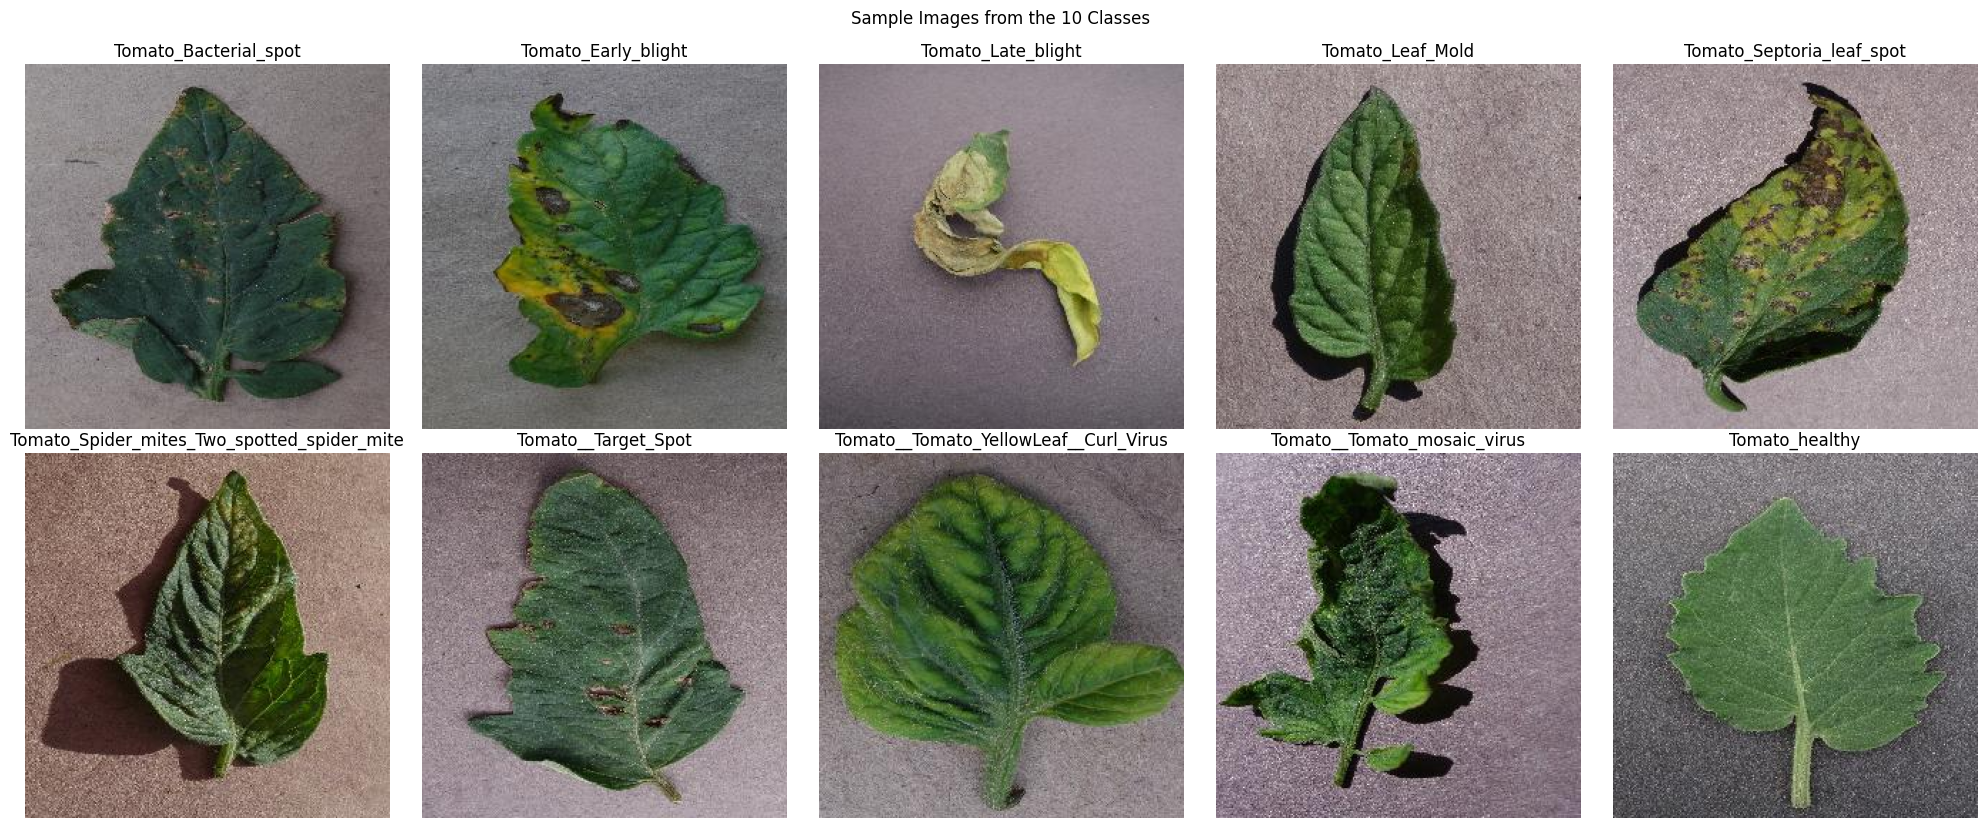

In [2]:
class_names = ds['train'].unique('disease_name')
class_names.sort()

num_classes = len(class_names)
print(f"There are {num_classes} classes: {class_names}")

samples = {}
for example in ds['train']:
    disease_name = example['disease_name']
    if disease_name not in samples:
        samples[disease_name] = example['image']
    if len(samples) == num_classes:
        break

fig, axes = plt.subplots(2, 5, figsize=(20, 8))
axes = axes.ravel()

for i, name in enumerate(class_names):
    ax = axes[i]
    ax.imshow(samples[name])
    ax.set_title(name)
    ax.axis('off')

plt.tight_layout()
plt.suptitle("Sample Images from the 10 Classes", y=1.03)
plt.show()

### 1-2-2. Checking Class Imbalance, Augmentation, Resizing and Splitting

Here we will first check for class imbalances in our data and then suggest a solution to fix it and implement said solution and split the data into a training and a validation set.

In order to check the class imbalance first the dataset will be converted into a pandas data frame and then a bar plot will be drawn to show the class distribution.

--- Dataset Class Distribution ---
                                  Disease Name  Image Count
0                        Tomato_Bacterial_spot         1000
1                          Tomato_Early_blight         1000
2                           Tomato_Late_blight         1000
3                             Tomato_Leaf_Mold          952
4                    Tomato_Septoria_leaf_spot         1000
5  Tomato_Spider_mites_Two_spotted_spider_mite         1000
6                          Tomato__Target_Spot         1000
7        Tomato__Tomato_YellowLeaf__Curl_Virus         1000
8                  Tomato__Tomato_mosaic_virus          373
9                               Tomato_healthy         1000


/tmp/ipykernel_3484/625145563.py:15: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Image Count', y='Disease Name', data=class_counts, palette='viridis', orient='h')


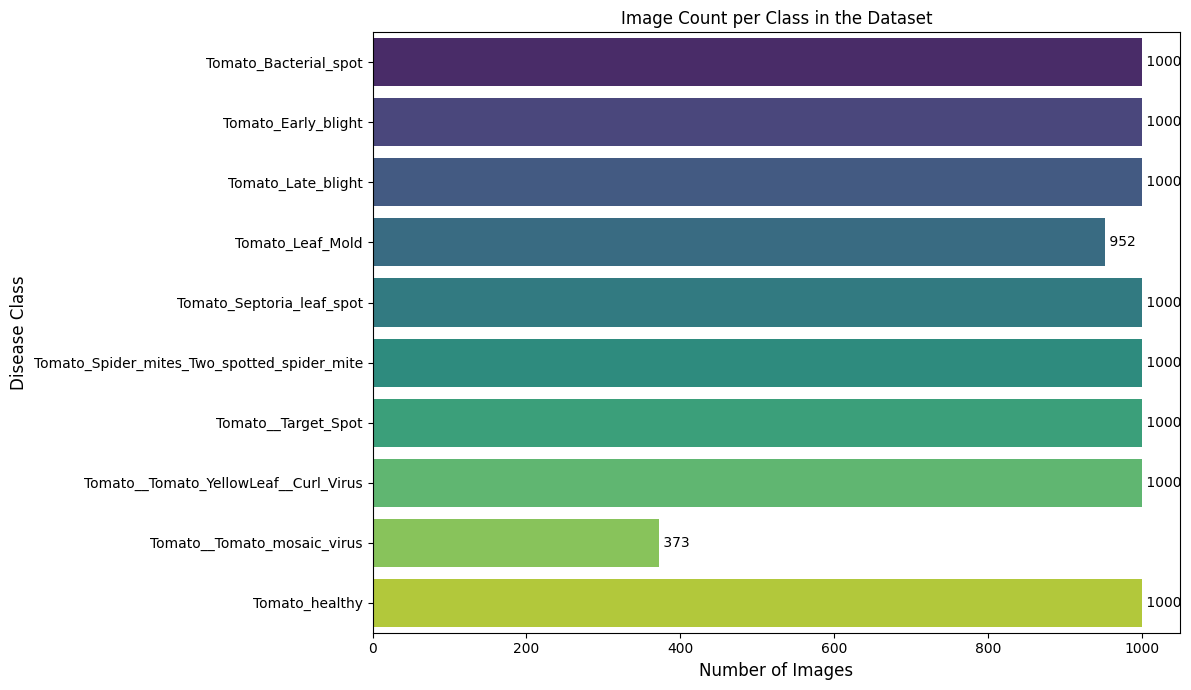

In [3]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

df = ds['train'].to_pandas()

class_counts = df['disease_name'].value_counts().reset_index()
class_counts.columns = ['Disease Name', 'Image Count']
class_counts = class_counts.sort_values(by='Disease Name').reset_index(drop=True)

print("--- Dataset Class Distribution ---")
print(class_counts.to_string())

plt.figure(figsize=(12, 7))
sns.barplot(x='Image Count', y='Disease Name', data=class_counts, palette='viridis', orient='h')
plt.title('Image Count per Class in the Dataset')
plt.xlabel('Number of Images', fontsize=12)
plt.ylabel('Disease Class', fontsize=12)
for index, value in enumerate(class_counts['Image Count']):
    plt.text(value, index, f' {value}', va='center')
plt.tight_layout()
plt.show()

From the diagram we can see only two classes have less than 1000 instances, Tomato_Leaf_Mold with 952 and Tomato__Tomato_mosaic_virus which has only 373 instances.

To mitigate this issue we have 3 options: Undersampling other classes, taking multiple samples of the classes with lower instances or augmentation. Since the first two approaches may reduce our performance we will perform augmentation, where in order to improve efficiency we will define an augmenter and augment instances of these two classes more than the other classes to achieve a more balanced dataset.

For our augmentation we define a horizontal and vertical flip, random rotation, zoom and contrast.

Note that due to the different input sizes of the ViT and Inception V3 models, we have created two different datasets with 64x64 and 299x299 images sizes respectively and we also make two datasets for each model, one for training and one for validation (with no augmentation on the validation dataset!). Similar to the paper we will use 90% of the data for training and 10% for validation

In [18]:
import tensorflow as tf

gpus = tf.config.list_physical_devices('GPU')
if gpus:
    try:
        for gpu in gpus:
            tf.config.experimental.set_memory_growth(gpu, True)
        print("Memory growth set for GPU")
    except RuntimeError as e:
        print(e)

class_names = sorted(ds['train'].unique('disease_name'))
num_classes = len(class_names)
name_to_int = {name: i for i, name in enumerate(class_names)}

def map_labels(example):
    example['label'] = name_to_int[example['disease_name']]
    return example

ds = ds.map(map_labels, num_proc=4)

train_validation_split = ds['train'].train_test_split(test_size=0.1, seed=42)
original_train_ds = train_validation_split['train']
original_validation_ds = train_validation_split['test']

data_augmentation_layers = tf.keras.Sequential([
    tf.keras.layers.RandomFlip("horizontal_and_vertical"),
    tf.keras.layers.RandomRotation(0.3),
    tf.keras.layers.RandomZoom(0.2),
    tf.keras.layers.RandomContrast(0.2),
], name="data_augmentation")

batch_size = 32

def create_pipeline(huggingface_ds, image_size, is_training, preprocess_fn=None):
    if is_training:
        datasets_per_class = []
        for i in range(num_classes):
            tf_class_ds = huggingface_ds.filter(
                lambda x: x['label'] == i
            ).to_tf_dataset(columns=['image', 'label'], shuffle=True)
            datasets_per_class.append(tf_class_ds)

        def train_preprocess(example):
            image, label = example['image'], example['label']
            image = tf.image.resize(image, [image_size, image_size])
            image = data_augmentation_layers(image)
            image = preprocess_fn(image) if preprocess_fn else tf.cast(image, tf.float32) / 255.0
            return image, label

        augmented_datasets = [
            d.map(train_preprocess, num_parallel_calls=tf.data.AUTOTUNE).repeat()
            for d in datasets_per_class
        ]
        balanced_dataset = tf.data.experimental.sample_from_datasets(
            datasets=augmented_datasets,
            weights=[1.0/num_classes] * num_classes
        )
        return balanced_dataset.batch(batch_size).prefetch(tf.data.AUTOTUNE)

    else:
        tf_validation_ds = huggingface_ds.to_tf_dataset(columns=['image', 'label'], shuffle=False)

        def validation_preprocess(example):
            image, label = example['image'], example['label']
            image = tf.image.resize(image, [image_size, image_size])
            image = preprocess_fn(image) if preprocess_fn else tf.cast(image, tf.float32) / 255.0
            return image, label

        return tf_validation_ds.map(validation_preprocess, num_parallel_calls=tf.data.AUTOTUNE).batch(batch_size).prefetch(tf.data.AUTOTUNE)

train_ds_vit = create_pipeline(original_train_ds, image_size=64, is_training=True)
validation_ds_vit = create_pipeline(original_validation_ds, image_size=64, is_training=False)

inception_preprocessor = tf.keras.applications.inception_v3.preprocess_input
train_ds_cnn = create_pipeline(original_train_ds, image_size=299, is_training=True, preprocess_fn=inception_preprocessor)
validation_ds_cnn = create_pipeline(original_validation_ds, image_size=299, is_training=False, preprocess_fn=inception_preprocessor)

Memory growth set for GPU


Filter: 100%|██████████| 8392/8392 [00:02<00:00, 3623.20 examples/s]


Now we will visualise some of the images to check everything has worked properly.

2025-06-12 11:41:35.270180: I tensorflow/core/framework/local_rendezvous.cc:407] Local rendezvous is aborting with status: CANCELLED: RecvAsync is cancelled.
	 [[{{node data_augmentation_1/random_rotation_1/Add/_22}}]] [type.googleapis.com/tensorflow.DerivedStatus='']
2025-06-12 11:41:35.270203: I tensorflow/core/framework/local_rendezvous.cc:407] Local rendezvous is aborting with status: CANCELLED: RecvAsync is cancelled.
	 [[{{node data_augmentation_1/random_rotation_1/Add/_22}}]]
	 [[GroupCrossDeviceControlEdges_0/NoOp/_27]] [type.googleapis.com/tensorflow.DerivedStatus='']
2025-06-12 11:41:35.270210: I tensorflow/core/framework/local_rendezvous.cc:426] Local rendezvous recv item cancelled. Key hash: 11084095213025682829
2025-06-12 11:41:35.270214: I tensorflow/core/framework/local_rendezvous.cc:426] Local rendezvous recv item cancelled. Key hash: 14713386856034405166
2025-06-12 11:41:35.270510: I tensorflow/core/framework/local_rendezvous.cc:407] Local rendezvous is aborting with s

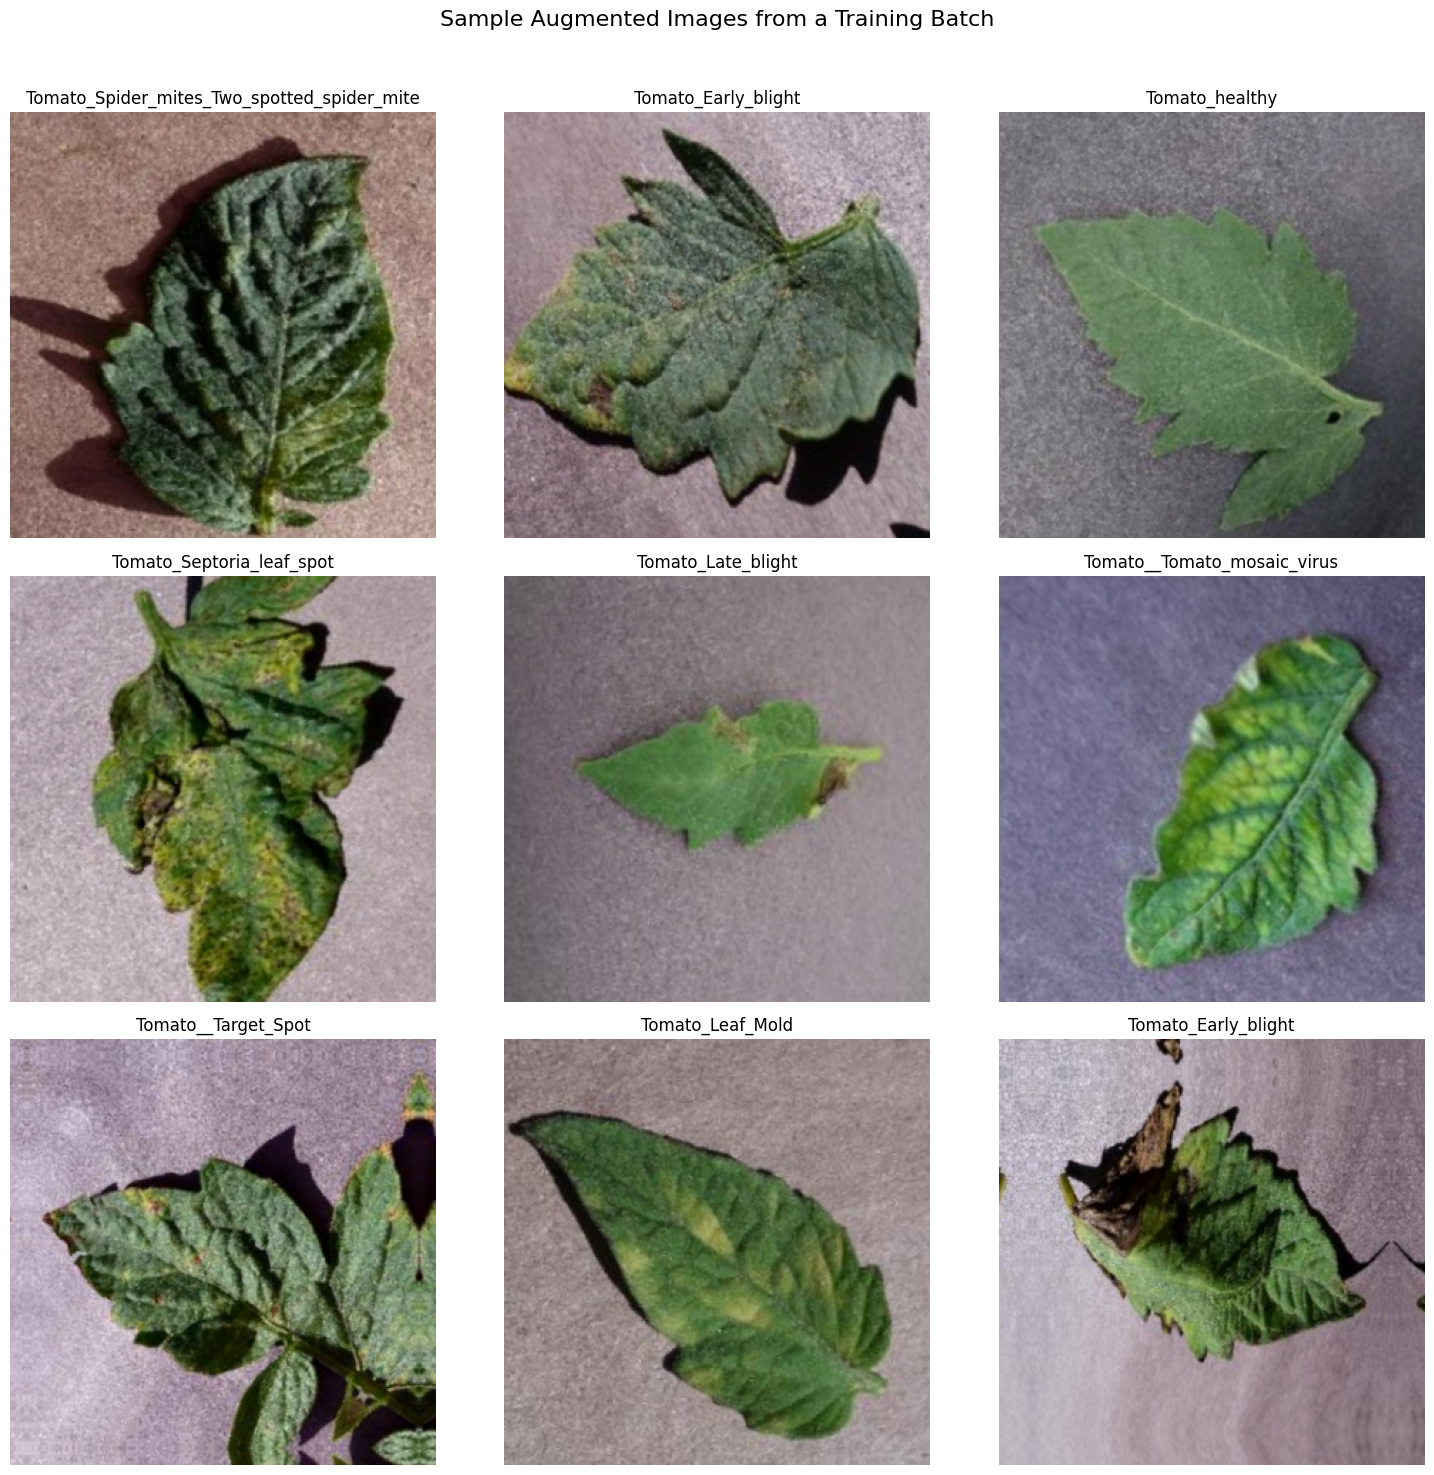

In [ ]:
import numpy as np

int_to_name = {i: name for i, name in enumerate(class_names)}

image_batch, label_batch = next(iter(train_ds_cnn))

def unprocess_for_display(image):
    image = (image + 1.0) / 2.0
    return np.clip(image, 0, 1)

plt.figure(figsize=(15, 15))
plt.suptitle("Sample Augmented Images from a Training Batch", fontsize=16)

for i in range(min(9, batch_size)):
    ax = plt.subplot(3, 3, i + 1)

    img_to_show = unprocess_for_display(image_batch[i])

    label_name = int_to_name[label_batch[i].numpy()]

    plt.imshow(img_to_show)
    plt.title(label_name)
    plt.axis("off")

plt.tight_layout(rect=[0, 0, 1, 0.96])
plt.show()

## 1-3. Training the CNN model (InceptionV3)

In this section we will be training the InceptionV3 model, but before we begin let's give a brief explanation about the architecture of this model.

### 1-3-1. How the Inception V3 Model Works

Inception V3 is a deep learning architecture and a type of convolutional neural network (CNN). At a high level, it's composed of convolution, polling, and fully connected layers. Its main goal is to be a highly effective and computationally efficient image classifier.

The key innovation of the inception family of models is its core building block, the inception module. Here's how it works:

1.  __Capturing Features at Multiple Scales:__ The primary purpose of the Inception module is to capture features at different scales by using multiple filter sizes within the same network layer. Instead of just choosing one size for a convolutional filter at a given layer, the inception module runs several different sized convolutions in parallel on the same input. This allows the model to simultaneously detect both small and larger features in the image.

2.  __Parallel Processing:__ An input to an Inception module is processed through multiple parallel branches. The outputs from all these parallel branches are then concatenated into a single, rich feature map that is passed to the next layer.

3.  __Final Classification:__ After the image passes through all the inception modules, the resulting features are processed by a final classifier. 

This architecture can be seen in the image below:

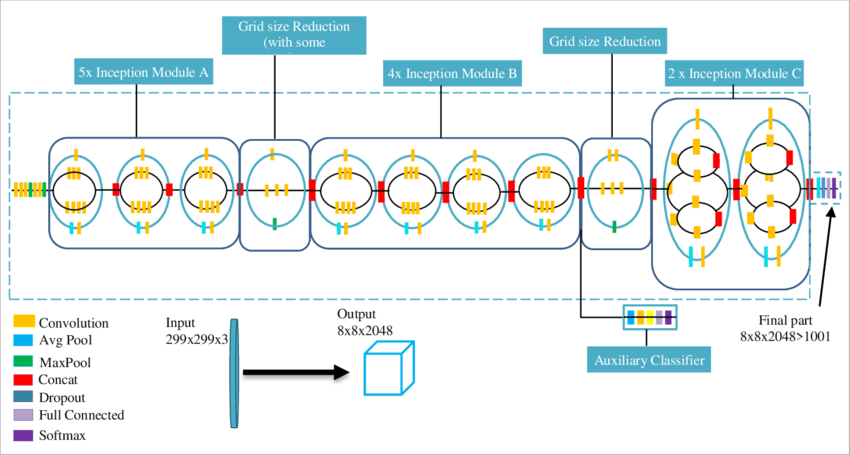

### 1-3-2. Loss function

The paper specifies using categorical cross-entropy as the loss function for training the models. Cross-entropy is the standard loss function for multi-class classification tasks. 

While categorical cross-entropy is the most common choice, other functions are also suitable for this task:

1.  __Focal Loss:__ This is a popular alternative and an enhancement of categorical cross-entropy. Focal Loss modifies the standard cross-entropy loss to focus more on misclassified examples. It dynamically down-weights the loss contribution from easy, well-classified examples, preventing them from dominating the training process. This can be particularly useful if there is a class imbalance.

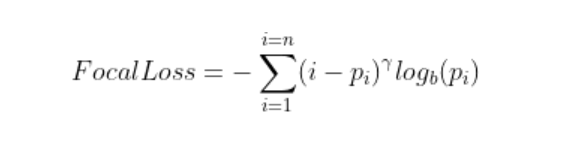

2.  __Kullback-Leibler (KL) Divergence Loss:__ KL Divergence is another function that measures how one probability distribution diverges from a second, expected probability distribution. For multi-class classification problems with one-hot encoded labels, KL Divergence is mathematically equivalent to categorical cross-entropy. While it could be used, it would be expected to produce the same results.

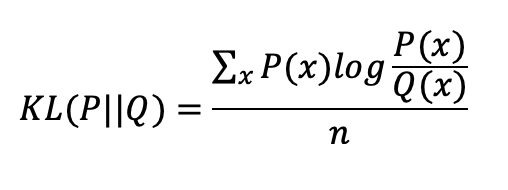

### 1-3-3. Training the model

The paper has stated that the InceptionV3 model was used with pretrained weights on ImageNet, but we will use both and untrained model and a pretrained model and train/fine tune each of them for 30 epochs and compare the results.

In [6]:
print("Model 1: Pre-trained InceptionV3")
base_model_pretrained = tf.keras.applications.InceptionV3(
    input_shape=(299, 299, 3),
    include_top=False,
    weights=None
)
base_model_pretrained.load_weights('inception_v3_weights_tf_dim_ordering_tf_kernels_notop.h5')

base_model_pretrained.trainable = False

model_pretrained = tf.keras.Sequential([
    base_model_pretrained,
    tf.keras.layers.Flatten(),
    tf.keras.layers.Dense(num_classes, activation='softmax')
], name="pretrained_cnn")

model_pretrained.compile(
    optimizer='adam',
    loss=tf.keras.losses.SparseCategoricalCrossentropy(),
    metrics=['accuracy']
)

print("Model 1 Summary:")
model_pretrained.summary()

print("Model 2: InceptionV3 From Scratch")
base_model_scratch = tf.keras.applications.InceptionV3(
    input_shape=(299, 299, 3),
    include_top=False,
    weights=None
)
base_model_scratch.trainable = True

model_scratch = tf.keras.Sequential([
    base_model_scratch,
    tf.keras.layers.Flatten(),
    tf.keras.layers.Dense(num_classes, activation='softmax')
], name="scratch_cnn")

model_scratch.compile(
    optimizer='adam',
    loss=tf.keras.losses.SparseCategoricalCrossentropy(),
    metrics=['accuracy']
)

print("Model 2 Summary:")
model_scratch.summary()

Model 1: Pre-trained InceptionV3
Model 1 Summary:


Model: "pretrained_cnn"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ inception_v3 (Functional)       │ (None, 8, 8, 2048)     │    21,802,784 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 131072)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 10)             │     1,310,730 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 23,113,514 (88.17 MB)

 Trainable params: 1,310,730 (5.00 MB)

...

Model: "scratch_cnn"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ inception_v3 (Functional)       │ (None, 8, 8, 2048)     │    21,802,784 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_1 (Flatten)             │ (None, 131072)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 10)             │     1,310,730 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 23,113,514 (88.17 MB)

 Trainable params: 23,079,082 (88.04 MB)

 Non-trainable params: 34,432 (134.50 KB)

Now we train the models.

In [ ]:
checkpoint_pretrained = tf.keras.callbacks.ModelCheckpoint(
    filepath='best_pretrained_model.keras',  
    monitor='val_accuracy',              
    mode='max',                          
    save_best_only=True,                 
    verbose=1                            
)


checkpoint_scratch = tf.keras.callbacks.ModelCheckpoint(
    filepath='best_scratch_model.keras',
    monitor='val_accuracy',
    mode='max',
    save_best_only=True,
    verbose=1
)


epochs = 30
steps_per_epoch = len(original_train_ds) // batch_size

print(f"Training Model 1 (Pre-trained) for {epochs} epochs")
history_pretrained = model_pretrained.fit(
    train_ds_cnn,
    validation_data=validation_ds_cnn,
    epochs=epochs,
    steps_per_epoch=steps_per_epoch,
    verbose=2,
    callbacks=[checkpoint_pretrained]  
)

print(f"Training Model 2 (From Scratch) for {epochs} epochs")
history_scratch = model_scratch.fit(
    train_ds_cnn,
    validation_data=validation_ds_cnn,
    epochs=epochs,
    steps_per_epoch=steps_per_epoch,
    verbose=2,
    callbacks=[checkpoint_scratch]  
)

Training Model 1 (Pre-trained) for 30 epochs
Epoch 1/30


I0000 00:00:1749715900.822789    3570 service.cc:152] XLA service 0x731f640036f0 initialized for platform CUDA (this does not guarantee that XLA will be used). Devices:
I0000 00:00:1749715900.822829    3570 service.cc:160]   StreamExecutor device (0): NVIDIA GeForce RTX 4060 Laptop GPU, Compute Capability 8.9
2025-06-12 11:41:41.066195: I tensorflow/compiler/mlir/tensorflow/utils/dump_mlir_util.cc:269] disabling MLIR crash reproducer, set env var `MLIR_CRASH_REPRODUCER_DIRECTORY` to enable.
I0000 00:00:1749715902.296634    3570 cuda_dnn.cc:529] Loaded cuDNN version 90701
2025-06-12 11:41:46.042647: W external/local_xla/xla/tsl/framework/bfc_allocator.cc:382] Garbage collection: deallocate free memory regions (i.e., allocations) so that we can re-allocate a larger region to avoid OOM due to memory fragmentation. If you see this message frequently, you are running near the threshold of the available device memory and re-allocation may incur great performance overhead. You may try smaller


Epoch 1: val_accuracy improved from -inf to 0.68703, saving model to best_pretrained_model.keras
262/262 - 57s - 218ms/step - accuracy: 0.6151 - loss: 6.3198 - val_accuracy: 0.6870 - val_loss: 4.3780
Epoch 2/30

Epoch 2: val_accuracy improved from 0.68703 to 0.75241, saving model to best_pretrained_model.keras
262/262 - 36s - 136ms/step - accuracy: 0.7452 - loss: 4.4251 - val_accuracy: 0.7524 - val_loss: 4.1833
Epoch 3/30

Epoch 3: val_accuracy improved from 0.75241 to 0.75777, saving model to best_pretrained_model.keras
262/262 - 36s - 138ms/step - accuracy: 0.7889 - loss: 3.7336 - val_accuracy: 0.7578 - val_loss: 4.0589
Epoch 4/30

Epoch 4: val_accuracy improved from 0.75777 to 0.79850, saving model to best_pretrained_model.keras
262/262 - 36s - 139ms/step - accuracy: 0.7946 - loss: 4.3045 - val_accuracy: 0.7985 - val_loss: 4.3188
Epoch 5/30

Epoch 5: val_accuracy did not improve from 0.79850
262/262 - 37s - 141ms/step - accuracy: 0.8225 - loss: 3.8797 - val_accuracy: 0.7899 - val_l

2025-06-12 11:47:49.551138: W tensorflow/core/kernels/data/prefetch_autotuner.cc:52] Prefetch autotuner tried to allocate 1572872 bytes after encountering the first element of size 1572872 bytes.This already causes the autotune ram budget to be exceeded. To stay within the ram budget, either increase the ram budget or reduce element size
2025-06-12 11:47:58.111530: W tensorflow/core/kernels/data/prefetch_autotuner.cc:52] Prefetch autotuner tried to allocate 1572872 bytes after encountering the first element of size 1572872 bytes.This already causes the autotune ram budget to be exceeded. To stay within the ram budget, either increase the ram budget or reduce element size
2025-06-12 11:48:09.537555: W tensorflow/core/kernels/data/prefetch_autotuner.cc:52] Prefetch autotuner tried to allocate 1572872 bytes after encountering the first element of size 1572872 bytes.This already causes the autotune ram budget to be exceeded. To stay within the ram budget, either increase the ram budget or 


Epoch 10: val_accuracy did not improve from 0.81672
262/262 - 36s - 139ms/step - accuracy: 0.8504 - loss: 3.8559 - val_accuracy: 0.7610 - val_loss: 7.9498
Epoch 11/30


...


Epoch 28: val_accuracy did not improve from 0.93891
262/262 - 78s - 298ms/step - accuracy: 0.9320 - loss: 0.1914 - val_accuracy: 0.8960 - val_loss: 0.2867
Epoch 29/30


2025-06-12 12:37:12.597600: W tensorflow/core/kernels/data/prefetch_autotuner.cc:52] Prefetch autotuner tried to allocate 1572872 bytes after encountering the first element of size 1572872 bytes.This already causes the autotune ram budget to be exceeded. To stay within the ram budget, either increase the ram budget or reduce element size
2025-06-12 12:37:36.926669: W tensorflow/core/kernels/data/prefetch_autotuner.cc:52] Prefetch autotuner tried to allocate 1572872 bytes after encountering the first element of size 1572872 bytes.This already causes the autotune ram budget to be exceeded. To stay within the ram budget, either increase the ram budget or reduce element size
2025-06-12 12:37:39.415340: W tensorflow/core/kernels/data/prefetch_autotuner.cc:52] Prefetch autotuner tried to allocate 1572872 bytes after encountering the first element of size 1572872 bytes.This already causes the autotune ram budget to be exceeded. To stay within the ram budget, either increase the ram budget or 


Epoch 29: val_accuracy did not improve from 0.93891
262/262 - 76s - 292ms/step - accuracy: 0.8536 - loss: 0.4595 - val_accuracy: 0.7449 - val_loss: 0.9023
Epoch 30/30


2025-06-12 12:38:34.245407: W tensorflow/core/kernels/data/prefetch_autotuner.cc:52] Prefetch autotuner tried to allocate 1572872 bytes after encountering the first element of size 1572872 bytes.This already causes the autotune ram budget to be exceeded. To stay within the ram budget, either increase the ram budget or reduce element size
2025-06-12 12:38:37.791678: W tensorflow/core/kernels/data/prefetch_autotuner.cc:52] Prefetch autotuner tried to allocate 1572872 bytes after encountering the first element of size 1572872 bytes.This already causes the autotune ram budget to be exceeded. To stay within the ram budget, either increase the ram budget or reduce element size
2025-06-12 12:38:57.116685: W tensorflow/core/kernels/data/prefetch_autotuner.cc:52] Prefetch autotuner tried to allocate 1572872 bytes after encountering the first element of size 1572872 bytes.This already causes the autotune ram budget to be exceeded. To stay within the ram budget, either increase the ram budget or 


Epoch 30: val_accuracy did not improve from 0.93891
262/262 - 76s - 290ms/step - accuracy: 0.9156 - loss: 0.2508 - val_accuracy: 0.8617 - val_loss: 0.4223


The pre-trained model managed to get an accuracy of 0.88317 on the validation set and the model trained from the scratch managed to get an accuracy of 0.93891.

Below we can see the training and validation accuracy and loss for both of the models.

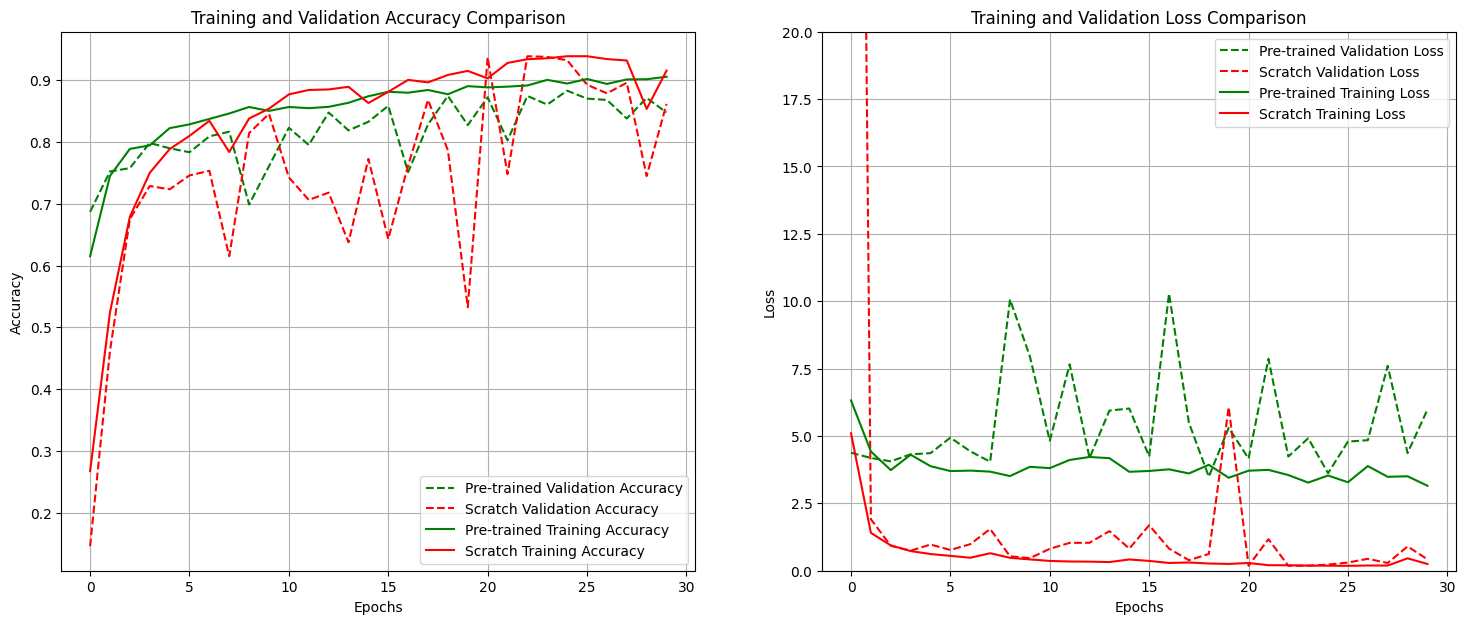

In [ ]:
acc_pretrained = history_pretrained.history['accuracy']
val_acc_pretrained = history_pretrained.history['val_accuracy']
loss_pretrained = history_pretrained.history['loss']
val_loss_pretrained = history_pretrained.history['val_loss']

acc_scratch = history_scratch.history['accuracy']
val_acc_scratch = history_scratch.history['val_accuracy']
loss_scratch = history_scratch.history['loss']
val_loss_scratch = history_scratch.history['val_loss']

epochs_range = range(epochs)

plt.figure(figsize=(18, 7))

plt.subplot(1, 2, 1)
plt.plot(epochs_range, val_acc_pretrained, label='Pre-trained Validation Accuracy', color='g', linestyle='--')
plt.plot(epochs_range, val_acc_scratch, label='Scratch Validation Accuracy', color='r', linestyle='--')
plt.plot(epochs_range, acc_pretrained, label='Pre-trained Training Accuracy', color='g')
plt.plot(epochs_range, acc_scratch, label='Scratch Training Accuracy', color='r')
plt.legend(loc='lower right')
plt.title('Training and Validation Accuracy Comparison')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.grid(True)

plt.subplot(1, 2, 2)
plt.plot(epochs_range, val_loss_pretrained, label='Pre-trained Validation Loss', color='g', linestyle='--')
plt.plot(epochs_range, val_loss_scratch, label='Scratch Validation Loss', color='r', linestyle='--')
plt.plot(epochs_range, loss_pretrained, label='Pre-trained Training Loss', color='g')
plt.plot(epochs_range, loss_scratch, label='Scratch Training Loss', color='r')
plt.legend(loc='upper right')
plt.title('Training and Validation Loss Comparison')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.grid(True)
plt.ylim(0, 20)

plt.show()

From the the plots we can see that the pre-trained model had a slightly lower accuracy (and higher loss) and the scratch model despite having a lower accuracy at the beginning managed to get a slightly higher accuracy at the end but overall its performance on the validation data was quite bumpy and had a lots of peaks and falls.

Generating predictions from the pre-trained model on the validation set...
30/30 ━━━━━━━━━━━━━━━━━━━━ 3s 106ms/step
Generating predictions from the pre-trained model on the validation set...
30/30 ━━━━━━━━━━━━━━━━━━━━ 3s 106ms/step


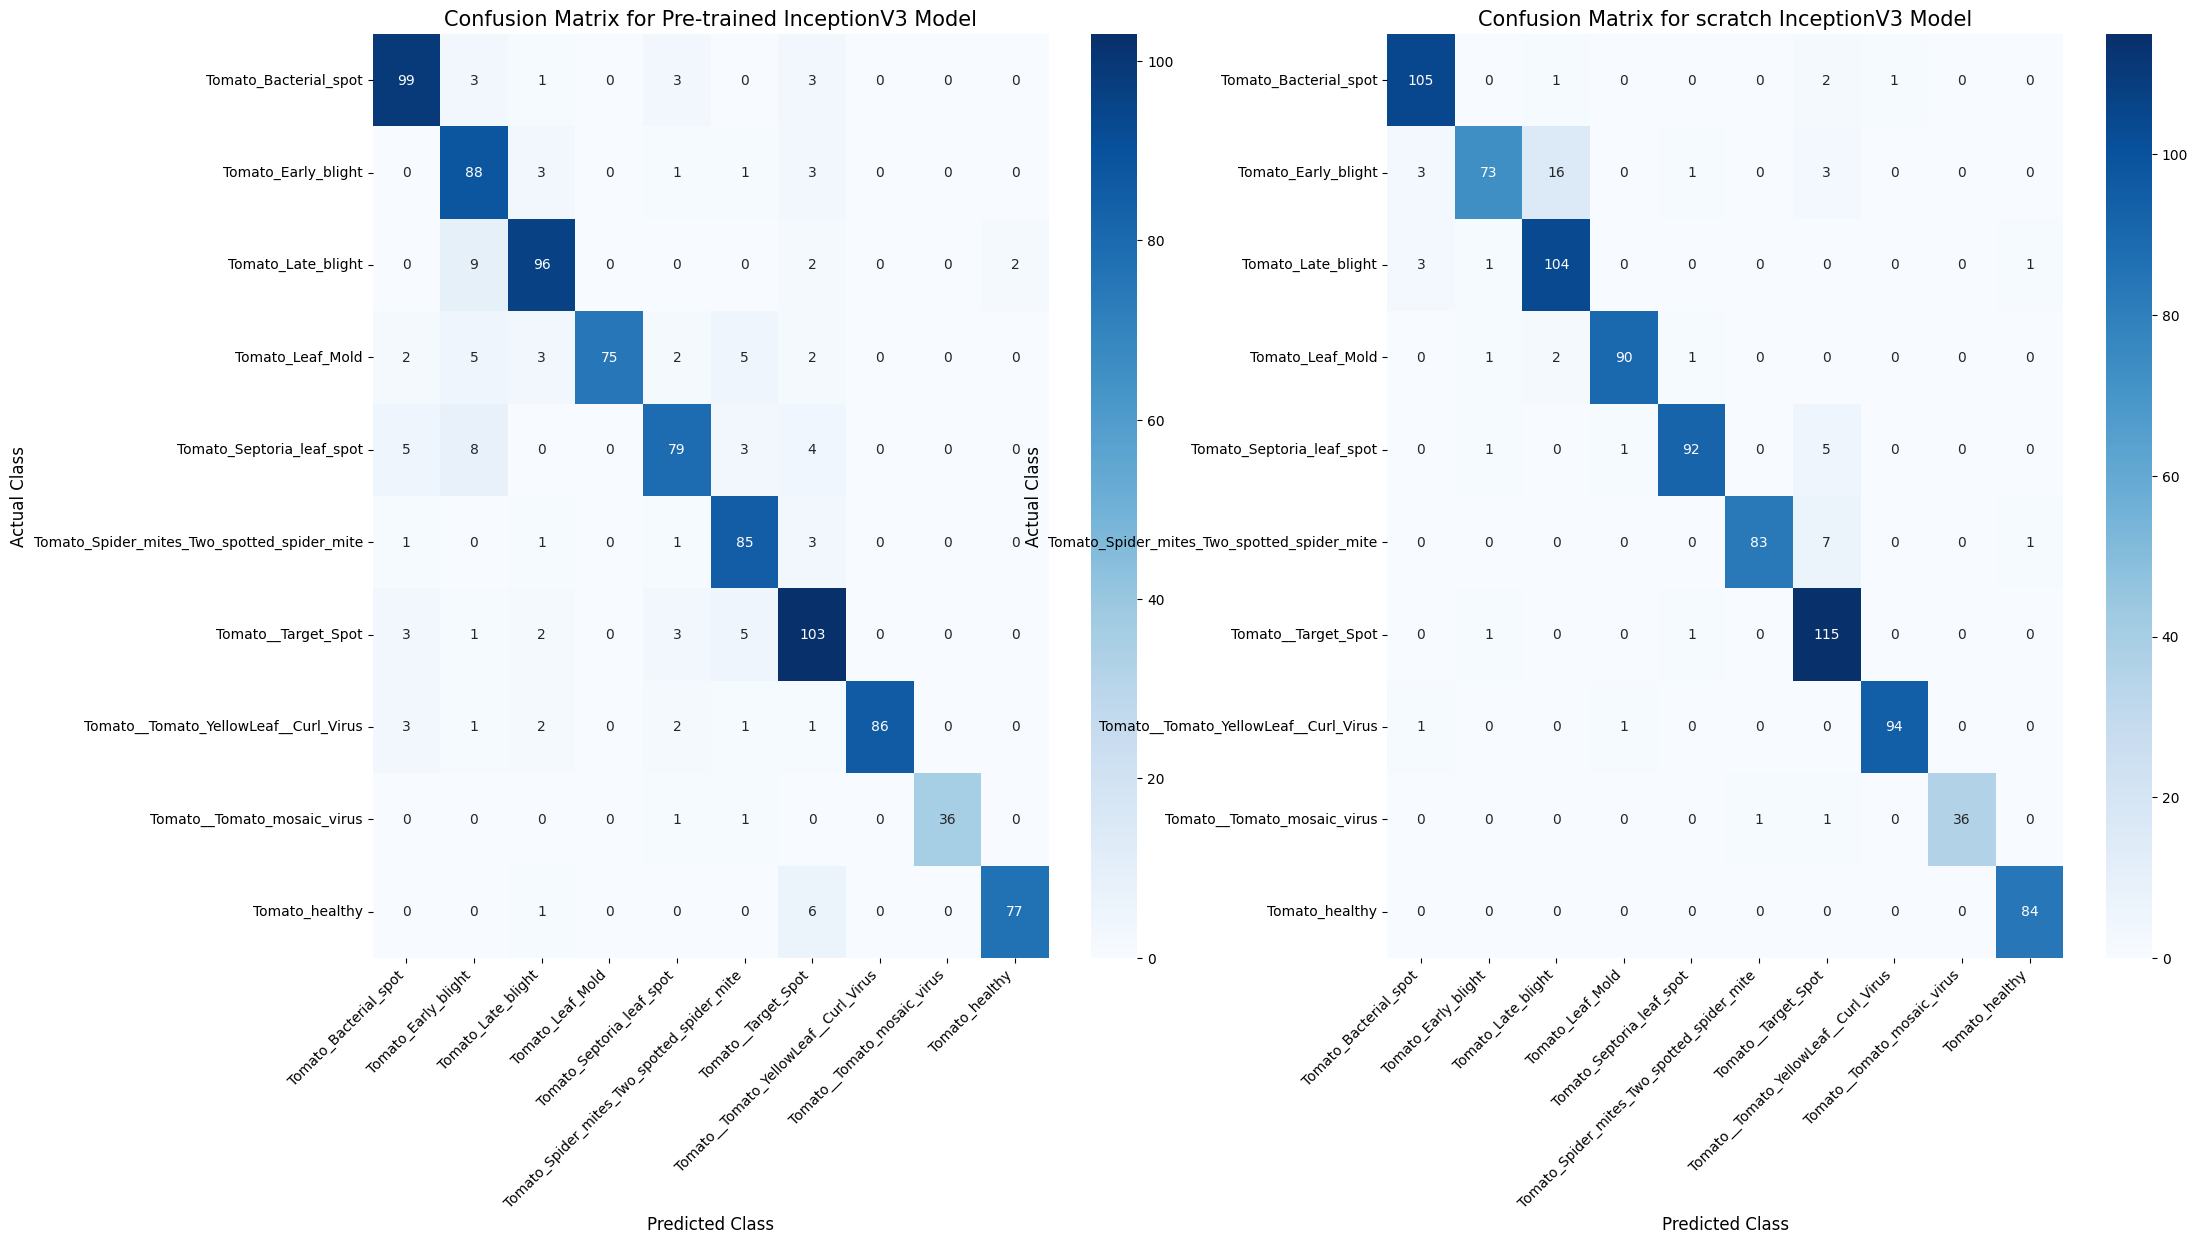

In [15]:
from sklearn.metrics import confusion_matrix

model_pretrained.load_weights('best_pretrained_model.keras')

print("Generating predictions from the pre-trained model on the validation set...")
y_pred_probabilities = model_pretrained.predict(validation_ds_cnn)
y_pred = np.argmax(y_pred_probabilities, axis=1)

y_true = np.concatenate([y for x, y in validation_ds_cnn], axis=0)

cm = confusion_matrix(y_true, y_pred)

plt.figure(figsize=(24, 12))
plt.subplot(1, 2, 1)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=class_names, yticklabels=class_names)
plt.title('Confusion Matrix for Pre-trained InceptionV3 Model', fontsize=15)
plt.ylabel('Actual Class', fontsize=12)
plt.xlabel('Predicted Class', fontsize=12)
plt.xticks(rotation=45, ha='right')
plt.yticks(rotation=0)

model_scratch.load_weights('best_scratch_model.keras')

print("Generating predictions from the pre-trained model on the validation set...")
y_pred_probabilities = model_scratch.predict(validation_ds_cnn)
y_pred = np.argmax(y_pred_probabilities, axis=1)

y_true = np.concatenate([y for x, y in validation_ds_cnn], axis=0)

cm = confusion_matrix(y_true, y_pred)

plt.subplot(1, 2, 2)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=class_names, yticklabels=class_names)
plt.title('Confusion Matrix for scratch InceptionV3 Model', fontsize=15)
plt.ylabel('Actual Class', fontsize=12)
plt.xlabel('Predicted Class', fontsize=12)
plt.xticks(rotation=45, ha='right')
plt.yticks(rotation=0)
plt.show()

From the confusion matrixes we can see that overall oth models had a good performance. The pretrained model had lots of scattered misclassification while most of the errors of the scratch model were in the class "Tomato_Early_blight.

## 1-4. Training the ViT model

### 1-4-1. Implementing the Paper's model

In this section the ViT model used in the paper has been implemented with a few changes that are as follows:

*   __Patches before MLP__: The paper's text states that "A network that can change the images into patches was introduced after the MLP layer". Which is fundamentally incorrect. Patch creation is the very first step in a ViT and the MLP is a component deep inside the Transformer blocks.

*   __Different transformer_dim__: Table 3 lists the "Transformer Dim" as 2. A projection dimension of 2 would compress all information from an image patch into just two numbers, destroying all the information and making learning impossible. This is very likely a mistake in the paper so we have used a projection_dimension of 64, a value that is consistent with the layer output shapes shown in the paper's own Table 4.

*   __Incomplete Model Summary__: The paper's Table 4 purports to be a model summary but completely omits the Multi-Head Attention layers. These layers are the core of the Transformer architecture. My implementation includes the standard Multi-Head Attention layers, as a ViT cannot function without them.

*   __Different Projection Layers Parameter__: Table 3 lists a hyperparameter "Projection Layers" with a value of 8. This is not standard terminology for a ViT. I have interpreted this to mean the number of stacked Transformer Encoder blocks so my implementation uses 8 Transformer blocks.

The rest of the parameters are as stated in the paper.

In [ ]:
from tensorflow import keras
from tensorflow.keras import layers

image_size = 64  
patch_size = 8   
num_patches = (image_size // patch_size) ** 2
projection_dimension = 64 
num_transformer_layers = 8 
num_heads = 4             
mpl_head_units = [2048, 1024] 

class Patches(layers.Layer):
    def __init__(self, patch_size, **kwargs):
        super().__init__(**kwargs)
        self.patch_size = patch_size

    def call(self, images):
        batch_size = tf.shape(images)[0]
        patches = tf.image.extract_patches(
            images=images,
            sizes=[1, self.patch_size, self.patch_size, 1],
            strides=[1, self.patch_size, self.patch_size, 1],
            rates=[1, 1, 1, 1],
            padding="VALID",
        )
        patch_dims = patches.shape[-1]
        patches = tf.reshape(patches, [batch_size, -1, patch_dims])
        return patches

class PatchEncoder(layers.Layer):
    def __init__(self, num_patches, projection_dim, **kwargs):
        super().__init__(**kwargs)
        self.num_patches = num_patches
        self.projection = layers.Dense(units=projection_dim)
        self.position_embedding = layers.Embedding(
            input_dim=num_patches, output_dim=projection_dim
        )

    def call(self, patch):
        positions = tf.range(start=0, limit=self.num_patches, delta=1)
        encoded = self.projection(patch) + self.position_embedding(positions)
        return encoded

def create_vit_classifier(num_classes):
    inputs = layers.Input(shape=(image_size, image_size, 3))
    patches = Patches(patch_size)(inputs)
    encoded_patches = PatchEncoder(num_patches, projection_dimension)(patches)

    for _ in range(num_transformer_layers):
        x1 = layers.LayerNormalization(epsilon=1e-6)(encoded_patches)
        attention_output = layers.MultiHeadAttention(
            num_heads=num_heads, key_dim=projection_dimension, dropout=0.1
        )(x1, x1)

        x2 = layers.Add()([attention_output, encoded_patches])

        x3 = layers.LayerNormalization(epsilon=1e-6)(x2)

        x3 = layers.Dense(units=projection_dimension * 2, activation=tf.nn.gelu)(x3)
        x3 = layers.Dropout(0.1)(x3)
        x3 = layers.Dense(units=projection_dimension, activation=tf.nn.gelu)(x3)
        x3 = layers.Dropout(0.1)(x3)

        encoded_patches = layers.Add()([x3, x2])

    representation = layers.LayerNormalization(epsilon=1e-6)(encoded_patches)
    representation = layers.Flatten()(representation)
    representation = layers.Dropout(0.5)(representation)

    features = layers.Dense(mpl_head_units[0], activation="relu")(representation)
    features = layers.Dropout(0.5)(features)
    features = layers.Dense(mpl_head_units[1], activation="relu")(features)
    features = layers.Dropout(0.5)(features)

    logits = layers.Dense(num_classes, activation="softmax")(features)

    model = keras.Model(inputs=inputs, outputs=logits)
    return model

vit_model = create_vit_classifier(num_classes=10) 
print("ViT Model Summary")
vit_model.summary()

ViT Model Summary


Model: "functional_6"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer_8       │ (None, 64, 64, 3) │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ patches_2 (Patches) │ (None, None, 192) │          0 │ input_layer_8[0]… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ patch_encoder_2     │ (None, 64, 64)    │     16,448 │ patches_2[0][0]   │
│ (PatchEncoder)      │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ layer_normalizatio… │ (None, 64, 64)    │        128 │ patch_encoder_2[… │
│ (LayerNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ multi_head_attenti… │ (None, 64, 64)    │     66,368 │ layer_normalizat… │
│ (MultiHeadAttentio… │                   │            │ layer_normalizat… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ add_32 (Add)        │ (None, 64, 64)    │          0 │ multi_head_atten… │
│                     │                   │            │ patch_encoder_2[… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ layer_normalizatio… │ (None, 64, 64)    │        128 │ add_32[0][0]      │
│ (LayerNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_43 (Dense)    │ (None, 64, 128)   │      8,320 │ layer_normalizat… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_55          │ (None, 64, 128)   │          0 │ dense_43[0][0]    │
│ (Dropout)           │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_44 (Dense)    │ (None, 64, 64)    │      8,256 │ dropout_55[0][0]  │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_56          │ (None, 64, 64)    │          0 │ dense_44[0][0]    │
│ (Dropout)           │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ add_33 (Add)        │ (None, 64, 64)    │          0 │ dropout_56[0][0], │
│                     │                   │            │ add_32[0][0]      │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ layer_normalizatio… │ (None, 64, 64)    │        128 │ add_33[0][0]      │
│ (LayerNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ multi_head_attenti… │ (None, 64, 64)    │     66,368 │ layer_normalizat… │
│ (MultiHeadAttentio… │                   │            │ layer_normalizat… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ add_34 (Add)        │ (None, 64, 64)    │          0 │ multi_head_atten… │
│                     │                   │            │ add_33[0][0]      │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ layer_normalizatio… │ (None, 64, 64)    │        128 │ add_34[0][0]      │
│ (LayerNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_45 (Dense)    │ (None, 64, 128)   │      8,320 │ layer_normalizat… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_58          │ (None, 64, 128)   │          0 │ dense_45[0][0]    │
│ (Dropout)           │                   │            │                 

 Total params: 11,181,258 (42.65 MB)

 Trainable params: 11,181,258 (42.65 MB)

 Non-trainable params: 0 (0.00 B)

### 1-4-2. Patch Embedding

The Patch Embedding layer is the critical first step in a ViT that adapts a standard transformer to work with 2D image data. It has three primary purposes:

* __1. Convert Image to a Sequence:__ The layer first divides the input image into a grid of smaller patches. It then flattens each patch into a long vector. By linearly flattening the patches of fixed-size blocks, this process effectively converts the 2D image into a 1D sequence of tokens, which is the input format of Transformer.

* __2. Create Learnable Embeddings:__ The flattened patches can have very large dimensions. To make them more manageable, each patch is fed through a standard linear projection layer (Dense layer). This projects the high-dimensional patch into a smaller, fixed-dimensional vector space.

* __3. Add Positional Information:__ A standard Transformer architecture has no inherent sense of the order of the tokens in a sequence. To overcome this the Patch Embedding layer adds learnable positional encodings to the patch embeddings. This step informs the model about the original location of each patch within the image, allowing it to understand the spatial relationships between them.

Changing the size of the patches has a significant and direct trade-off between model performance and computational cost.

Reducing the patch size results in longer input sequence for the Transformer to process.But smaller patches allow the model to see more fine-grained detail in the image, which can potentially lead to higher accuracy. On the other had however a longer sequence increases memory usage and the number of calculations, making the model much slower to train.

Increasing patch size results in a much shorter input sequence for the Transformer, which average out more detail. Fine-grained features could be lost within a single large patch, potentially leading to lower accuracy.But the shorter sequence makes the model faster and more memory-efficient.

### 1-4-3. Training the model

In [ ]:
learning_rate = 0.001
weight_decay = 0.0001

optimizer = tf.keras.optimizers.AdamW(
    learning_rate=learning_rate, weight_decay=weight_decay
)

vit_model.compile(
    optimizer=optimizer,
    loss=tf.keras.losses.SparseCategoricalCrossentropy(),
    metrics=["accuracy"],
)

checkpoint_vit = tf.keras.callbacks.ModelCheckpoint(
    filepath='best_vit_model.keras',  
    monitor='val_accuracy',          
    mode='max',                      
    save_best_only=True,             
    verbose=1                        
)

steps_per_epoch = len(original_train_ds) // batch_size
epochs = 30

print(f"Starting ViT Model Training for {epochs} epochs")

history_vit = vit_model.fit(
    train_ds_vit,
    validation_data=validation_ds_vit,
    epochs=epochs,
    steps_per_epoch=steps_per_epoch,
    callbacks=[checkpoint_vit]  
)

Starting ViT Model Training for 30 epochs
Epoch 1/30
262/262 ━━━━━━━━━━━━━━━━━━━━ 0s 60ms/step - accuracy: 0.1064 - loss: 3.2642
Epoch 1: val_accuracy improved from -inf to 0.11683, saving model to best_vit_model.keras
262/262 ━━━━━━━━━━━━━━━━━━━━ 41s 82ms/step - accuracy: 0.1064 - loss: 3.2619 - val_accuracy: 0.1168 - val_loss: 2.3267
Epoch 2/30
262/262 ━━━━━━━━━━━━━━━━━━━━ 0s 61ms/step - accuracy: 0.1107 - loss: 2.3291
Epoch 2: val_accuracy improved from 0.11683 to 0.13398, saving model to best_vit_model.keras
262/262 ━━━━━━━━━━━━━━━━━━━━ 19s 72ms/step - accuracy: 0.1107 - loss: 2.3291 - val_accuracy: 0.1340 - val_loss: 2.2580
Epoch 3/30
185/262 ━━━━━━━━━━━━━━━━━━━━ 4s 61ms/step - accuracy: 0.1129 - loss: 2.3204

2025-06-12 15:02:56.280873: W tensorflow/core/kernels/data/prefetch_autotuner.cc:52] Prefetch autotuner tried to allocate 1572872 bytes after encountering the first element of size 1572872 bytes.This already causes the autotune ram budget to be exceeded. To stay within the ram budget, either increase the ram budget or reduce element size


262/262 ━━━━━━━━━━━━━━━━━━━━ 0s 61ms/step - accuracy: 0.1120 - loss: 2.3196
Epoch 3: val_accuracy did not improve from 0.13398
262/262 ━━━━━━━━━━━━━━━━━━━━ 19s 71ms/step - accuracy: 0.1120 - loss: 2.3196 - val_accuracy: 0.0568 - val_loss: 2.2793
Epoch 4/30
 16/262 ━━━━━━━━━━━━━━━━━━━━ 8s 33ms/step - accuracy: 0.1080 - loss: 2.3180

2025-06-12 15:03:04.261687: W tensorflow/core/kernels/data/prefetch_autotuner.cc:52] Prefetch autotuner tried to allocate 1572872 bytes after encountering the first element of size 1572872 bytes.This already causes the autotune ram budget to be exceeded. To stay within the ram budget, either increase the ram budget or reduce element size
2025-06-12 15:03:04.363375: W tensorflow/core/kernels/data/prefetch_autotuner.cc:52] Prefetch autotuner tried to allocate 1572872 bytes after encountering the first element of size 1572872 bytes.This already causes the autotune ram budget to be exceeded. To stay within the ram budget, either increase the ram budget or reduce element size


 47/262 ━━━━━━━━━━━━━━━━━━━━ 7s 37ms/step - accuracy: 0.1137 - loss: 2.3079

...

227/262 ━━━━━━━━━━━━━━━━━━━━ 1s 53ms/step - accuracy: 0.8767 - loss: 0.3620

2025-06-12 15:10:37.414551: W tensorflow/core/kernels/data/prefetch_autotuner.cc:52] Prefetch autotuner tried to allocate 1572872 bytes after encountering the first element of size 1572872 bytes.This already causes the autotune ram budget to be exceeded. To stay within the ram budget, either increase the ram budget or reduce element size


262/262 ━━━━━━━━━━━━━━━━━━━━ 0s 53ms/step - accuracy: 0.8761 - loss: 0.3643

2025-06-12 15:10:39.596918: W tensorflow/core/kernels/data/prefetch_autotuner.cc:52] Prefetch autotuner tried to allocate 1572872 bytes after encountering the first element of size 1572872 bytes.This already causes the autotune ram budget to be exceeded. To stay within the ram budget, either increase the ram budget or reduce element size
2025-06-12 15:10:39.942638: W tensorflow/core/kernels/data/prefetch_autotuner.cc:52] Prefetch autotuner tried to allocate 1572872 bytes after encountering the first element of size 1572872 bytes.This already causes the autotune ram budget to be exceeded. To stay within the ram budget, either increase the ram budget or reduce element size



Epoch 30: val_accuracy did not improve from 0.88853
262/262 ━━━━━━━━━━━━━━━━━━━━ 16s 62ms/step - accuracy: 0.8761 - loss: 0.3644 - val_accuracy: 0.8317 - val_loss: 0.4807


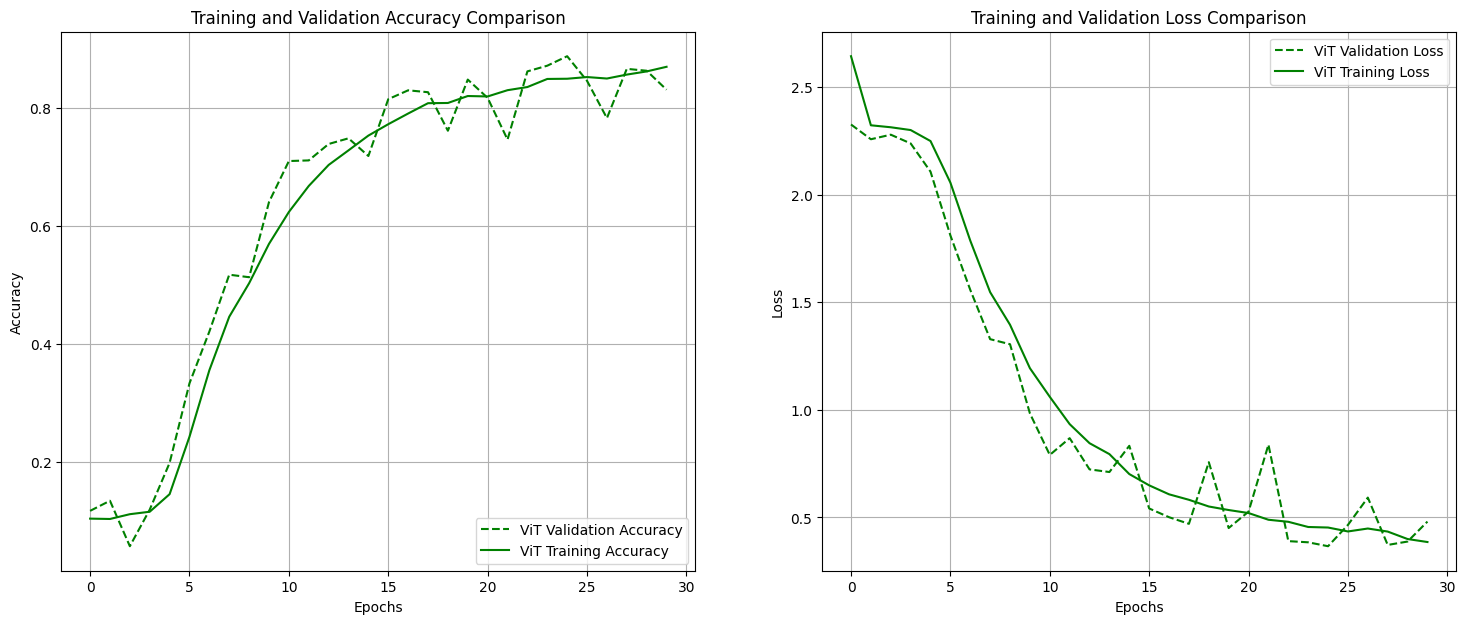

In [24]:
acc_vit = history_vit.history['accuracy']
val_acc_vit = history_vit.history['val_accuracy']
loss_vit = history_vit.history['loss']
val_loss_vit = history_vit.history['val_loss']

epochs_range = range(epochs)

plt.figure(figsize=(18, 7))

plt.subplot(1, 2, 1)
plt.plot(epochs_range, val_acc_vit, label='ViT Validation Accuracy', color='g', linestyle='--')
plt.plot(epochs_range, acc_vit, label='ViT Training Accuracy', color='g')
plt.legend(loc='lower right')
plt.title('Training and Validation Accuracy Comparison')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.grid(True)

plt.subplot(1, 2, 2)
plt.plot(epochs_range, val_loss_vit, label='ViT Validation Loss', color='g', linestyle='--')
plt.plot(epochs_range, loss_vit, label='ViT Training Loss', color='g')
plt.legend(loc='upper right')
plt.title('Training and Validation Loss Comparison')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.grid(True)

plt.show()

We can see that the model has learned the dataset properly without overfitting and managed to achieve an accuracy of 88% on the validation dataset.

30/30 ━━━━━━━━━━━━━━━━━━━━ 2s 54ms/step


(array([0.5, 1.5, 2.5, 3.5, 4.5, 5.5, 6.5, 7.5, 8.5, 9.5]),
 [Text(0, 0.5, 'Tomato_Bacterial_spot'),
  Text(0, 1.5, 'Tomato_Early_blight'),
  Text(0, 2.5, 'Tomato_Late_blight'),
  Text(0, 3.5, 'Tomato_Leaf_Mold'),
  Text(0, 4.5, 'Tomato_Septoria_leaf_spot'),
  Text(0, 5.5, 'Tomato_Spider_mites_Two_spotted_spider_mite'),
  Text(0, 6.5, 'Tomato__Target_Spot'),
  Text(0, 7.5, 'Tomato__Tomato_YellowLeaf__Curl_Virus'),
  Text(0, 8.5, 'Tomato__Tomato_mosaic_virus'),
  Text(0, 9.5, 'Tomato_healthy')])

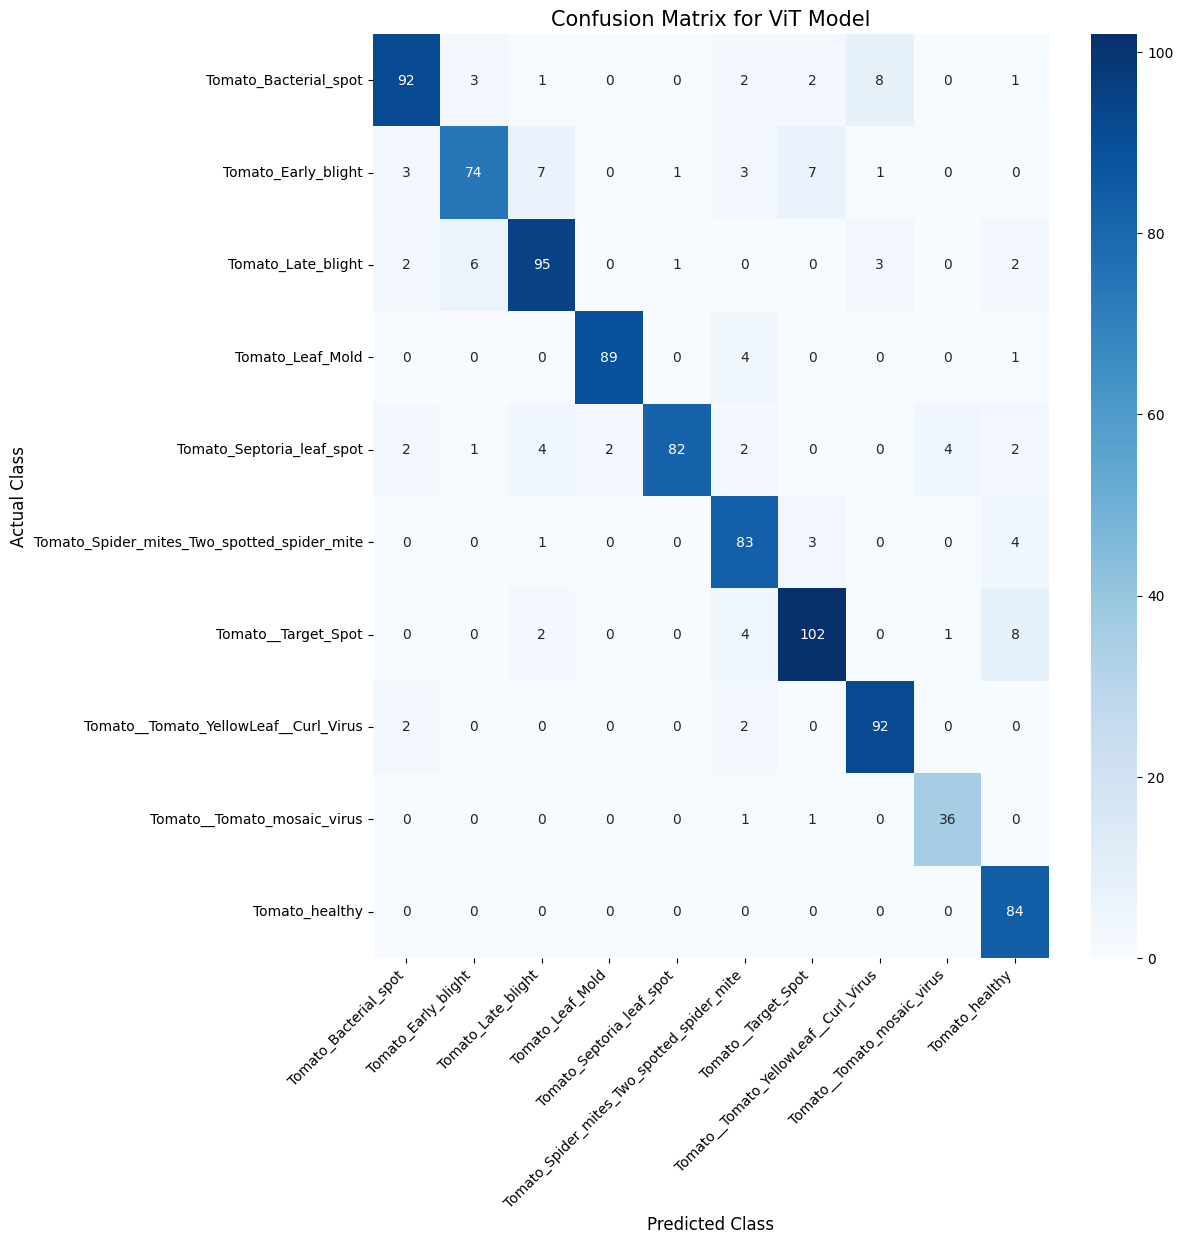

In [ ]:
from sklearn.metrics import confusion_matrix

vit_model.load_weights('best_vit_model.keras')

y_pred_probabilities = vit_model.predict(validation_ds_vit)
y_pred = np.argmax(y_pred_probabilities, axis=1)

y_true = np.concatenate([y for x, y in validation_ds_vit], axis=0)

cm = confusion_matrix(y_true, y_pred)

plt.figure(figsize=(24, 12))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=class_names, yticklabels=class_names)
plt.title('Confusion Matrix for ViT Model', fontsize=15)
plt.ylabel('Actual Class', fontsize=12)
plt.xlabel('Predicted Class', fontsize=12)
plt.xticks(rotation=45, ha='right')
plt.yticks(rotation=0)

From the confusion matrix we can see the misclassifications of the model were distributed rather equally but even the ViT model had some issues classifying the "Tomato_Early_blight" class!

## 1-5. Analysing the Results

To analyze the performance of the models we will prepare the following tables

In [28]:
from sklearn.metrics import classification_report, accuracy_score

model_pretrained.load_weights('best_pretrained_model.keras')
model_scratch.load_weights('best_scratch_model.keras')
vit_model.load_weights('best_vit_model.keras')

y_true_cnn = np.concatenate([y for x, y in validation_ds_cnn], axis=0)
preds_pretrained_probs = model_pretrained.predict(validation_ds_cnn)
y_pred_pretrained = np.argmax(preds_pretrained_probs, axis=1)
preds_scratch_probs = model_scratch.predict(validation_ds_cnn)
y_pred_scratch = np.argmax(preds_scratch_probs, axis=1)

y_true_vit = np.concatenate([y for x, y in validation_ds_vit], axis=0)
preds_vit_probs = vit_model.predict(validation_ds_vit)
y_pred_vit = np.argmax(preds_vit_probs, axis=1)

models_metrics = []

report_pretrained = classification_report(y_true_cnn, y_pred_pretrained, output_dict=True)
models_metrics.append({
    'Model': '1. CNN (Pre-trained)',
    'Accuracy': report_pretrained['accuracy'],
    'Precision (Macro Avg)': report_pretrained['macro avg']['precision'],
    'Recall (Macro Avg)': report_pretrained['macro avg']['recall'],
    'F1-Score (Macro Avg)': report_pretrained['macro avg']['f1-score']
})

report_scratch = classification_report(y_true_cnn, y_pred_scratch, output_dict=True)
models_metrics.append({
    'Model': '2. CNN (From Scratch)',
    'Accuracy': report_scratch['accuracy'],
    'Precision (Macro Avg)': report_scratch['macro avg']['precision'],
    'Recall (Macro Avg)': report_scratch['macro avg']['recall'],
    'F1-Score (Macro Avg)': report_scratch['macro avg']['f1-score']
})

report_vit = classification_report(y_true_vit, y_pred_vit, output_dict=True)
models_metrics.append({
    'Model': '3. ViT (From Scratch)',
    'Accuracy': report_vit['accuracy'],
    'Precision (Macro Avg)': report_vit['macro avg']['precision'],
    'Recall (Macro Avg)': report_vit['macro avg']['recall'],
    'F1-Score (Macro Avg)': report_vit['macro avg']['f1-score']
})

df_summary = pd.DataFrame(models_metrics)
print("Overall Model Performance Comparison")
print(df_summary.to_string())



print("Detailed Report: 1. CNN (Pre-trained)")
print(classification_report(y_true_cnn, y_pred_pretrained, target_names=class_names))

print("Detailed Report: 2. CNN (From Scratch)")
print(classification_report(y_true_cnn, y_pred_scratch, target_names=class_names))

print("Detailed Report: 3. ViT (From Scratch)")
print(classification_report(y_true_vit, y_pred_vit, target_names=class_names))

 1/30 ━━━━━━━━━━━━━━━━━━━━ 3s 137ms/step

2025-06-12 16:40:06.777471: I tensorflow/core/framework/local_rendezvous.cc:407] Local rendezvous is aborting with status: OUT_OF_RANGE: End of sequence


30/30 ━━━━━━━━━━━━━━━━━━━━ 3s 107ms/step
30/30 ━━━━━━━━━━━━━━━━━━━━ 3s 105ms/step
30/30 ━━━━━━━━━━━━━━━━━━━━ 2s 56ms/step
Overall Model Performance Comparison
                   Model  Accuracy  Precision (Macro Avg)  Recall (Macro Avg)  F1-Score (Macro Avg)
0   1. CNN (Pre-trained)  0.883173               0.900804            0.887579              0.891404
1  2. CNN (From Scratch)  0.938907               0.949674            0.938612              0.942098
2  3. ViT (From Scratch)  0.888532               0.890462            0.895111              0.890284
Detailed Report: 1. CNN (Pre-trained)
                                             precision    recall  f1-score   support

                      Tomato_Bacterial_spot       0.88      0.91      0.89       109
                        Tomato_Early_blight       0.77      0.92      0.83        96
                         Tomato_Late_blight       0.88      0.88      0.88       109
                           Tomato_Leaf_Mold       1.00      0.

From the tables above we can see that the scratch CNN model had the best overall performance with 93.8% accuracy (and 0.94 f1-score). The pre-trained CNN model and the ViT model had similar performance with about 90% accuracy (and 0.89 f1-score).

Given the fact that the InceptionV3 model has double the amount of parameters of the ViT (22M compared to 11M) for more lightweight application (like the use in a smart phone app as suggested in the paper) it makes more sense to use the ViT model.

This is especially true given the fact that the ViT model might have even achieved a higher accuracy with more training (more epochs), the same isn't true about the CNN model as it's validation accuracy was going down towards the end of the training showing sings of overfitting.

Another way to improve the models and especially ViT would be to use more data (or more aggressive data augmentation) as unlike CNN models, transformers don't have an understating of different shape and more data can help them figure them out more accurately.